# Tutorial 6 — Split-Half Reliability & Precision

**Split-half reliability**: does a measure give consistent values on
independent halves of the data? Uses the Spearman-Brown correction.

**Precision**: how quickly does a measure degrade when confidence ratings
are artificially corrupted toward the anti-metacognitive direction?

> **Speed note** — MLE-based measures (meta-d', metaNoise, metaUncertainty)
> are excluded here because each call takes 3–5 seconds and both analyses
> require hundreds of calls. Fast non-MLE measures (d', AUC2, Gamma, Phi)
> are used throughout. The concepts and code structure are identical for
> any measure.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from metasignal import stdpy

n_ratings = 4
FAST_LABELS = ["d'", "AUC2", "Gamma", "Phi"]

def simulate_subject(seed, n_trials=400, accuracy=0.78):
    r = np.random.default_rng(seed)
    stim    = r.choice([0, 1], n_trials)
    resp    = np.where(r.random(n_trials) < accuracy, stim, 1 - stim)
    correct = stim == resp
    conf    = np.where(
        correct, r.integers(3, n_ratings + 1, n_trials),
        r.integers(1, 3, n_trials),
    )
    return stim, resp, conf

def fast_measures(stim, resp, conf):
    """Return [d', AUC2, Gamma, Phi] — all O(n), no MLE."""
    try:
        dp, c, _ = stdpy.compute_sdt_resp(stim, resp)
    except Exception:
        return np.full(4, np.nan)
    nr_s1, nr_s2 = stdpy.trials_to_counts(stim, resp, conf, n_ratings)
    return np.array([
        float(dp),
        stdpy.compute_type2_auc(nr_s1, nr_s2),
        stdpy.compute_gamma(nr_s1, nr_s2),
        stdpy.compute_phi(nr_s1, nr_s2),
    ])

n_subjects = 30
dataset    = [simulate_subject(i) for i in range(n_subjects)]
print(f"Simulated {n_subjects} subjects, 400 trials each")


Simulated 30 subjects, 400 trials each


## Split-half reliability

Split each subject into **odd** and **even** trials, compute measures on each
half, correlate, then apply Spearman-Brown correction:

$$r_{SB} = \frac{2r}{1+r}$$

In [2]:
# split[subject, half, measure] — fast measures only
split = np.full((n_subjects, 2, 4), np.nan)

for s_idx, (stim, resp, conf) in enumerate(dataset):
    idx_odd  = np.arange(0, len(stim), 2)
    idx_even = np.arange(1, len(stim), 2)
    for half_idx, idx in enumerate([idx_odd, idx_even]):
        split[s_idx, half_idx] = fast_measures(stim[idx], resp[idx], conf[idx])

print("Split array shape:", split.shape)


Split array shape: (30, 2, 4)


In [3]:
def spearman_brown(r):
    return 2 * r / (1 + r) if not np.isnan(r) else np.nan

sb_vals = []
print(f"{'Measure':<8} {'Pearson r':>10} {'SB-corrected':>14}")
print("-" * 36)
for m, name in enumerate(FAST_LABELS):
    x, y = split[:, 0, m], split[:, 1, m]
    ok   = ~np.isnan(x) & ~np.isnan(y)
    if ok.sum() >= 5:
        r, _ = pearsonr(x[ok], y[ok])
        sb   = spearman_brown(r)
        sb_vals.append(sb)
        print(f"{name:<8} {r:10.3f} {sb:14.3f}")
    else:
        sb_vals.append(np.nan)
        print(f"{name:<8} {'NaN':>10} {'NaN':>14}")


Measure   Pearson r   SB-corrected
------------------------------------
d'            0.451          0.622
AUC2            nan            nan
Gamma           nan            nan
Phi           0.187          0.315


/var/folders/2f/1mng0xs503787mwn287f9_d00000gn/T/ipykernel_8215/2874749777.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(x[ok], y[ok])


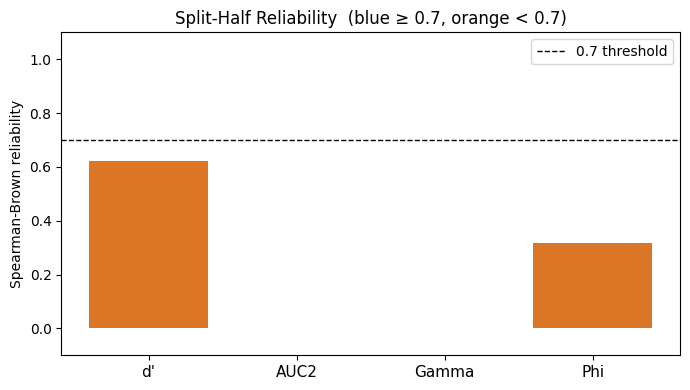

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(FAST_LABELS))
colors = ["#0072b2" if (v is not None and not np.isnan(v) and v >= 0.7) else "#d55e00"
          for v in sb_vals]

ax.bar(x, [v if v is not None and not np.isnan(v) else 0 for v in sb_vals],
       color=colors, alpha=0.85)
ax.axhline(0.7, color="k", linewidth=1.0, linestyle="--", label="0.7 threshold")
ax.set_xticks(x)
ax.set_xticklabels(FAST_LABELS, fontsize=11)
ax.set_ylabel("Spearman-Brown reliability")
ax.set_ylim(-0.1, 1.1)
ax.set_title("Split-Half Reliability  (blue ≥ 0.7, orange < 0.7)")
ax.legend()
plt.tight_layout()
plt.show()


## Precision under confidence corruption

Shift a proportion of trials toward anti-metacognitive confidence (correct →
lower conf; incorrect → higher conf) and measure how much each measure drops,
normalised by the across-subject SD.

In [5]:
def corrupt_confidence(stim, resp, conf, proportion, rng):
    c       = conf.copy().astype(float)
    correct = (stim == resp)
    n_c     = int(np.round(proportion * len(c)))
    idx     = rng.choice(len(c), size=n_c, replace=False)
    for i in idx:
        c[i] = max(1, c[i] - 1) if correct[i] else min(n_ratings, c[i] + 1)
    return c

PROPORTIONS = [0.0, 0.02, 0.04, 0.06]

base    = np.array([fast_measures(s, r, c) for s, r, c in dataset])
base_sd = np.nanstd(base, axis=0, ddof=1)
base_sd[base_sd == 0] = np.nan

drops = np.zeros((len(PROPORTIONS), 4))
for pi, prop in enumerate(PROPORTIONS):
    if prop == 0.0:
        continue
    corrupted = np.array([
        fast_measures(
            stim, resp,
            corrupt_confidence(stim, resp, conf, prop,
                               np.random.default_rng(s_idx * 100 + pi)).astype(int),
        )
        for s_idx, (stim, resp, conf) in enumerate(dataset)
    ])
    drops[pi] = np.nanmean((base - corrupted) / base_sd[np.newaxis, :], axis=0)

print("Precision drops:")
print(f"{'Prop':>6}", "  ".join(f"{n:>8}" for n in FAST_LABELS))
for prop, row in zip(PROPORTIONS, drops):
    print(f"{int(prop*100):>5}%  " + "  ".join(f"{v:8.3f}" for v in row))


Precision drops:
  Prop       d'      AUC2     Gamma       Phi
    0%     0.000     0.000     0.000     0.000
    2%     0.000       nan       nan     1.216
    4%     0.000       nan       nan     2.418
    6%     0.000       nan       nan     3.449


/var/folders/2f/1mng0xs503787mwn287f9_d00000gn/T/ipykernel_8215/4260032765.py:28: RuntimeWarning: Mean of empty slice
  drops[pi] = np.nanmean((base - corrupted) / base_sd[np.newaxis, :], axis=0)


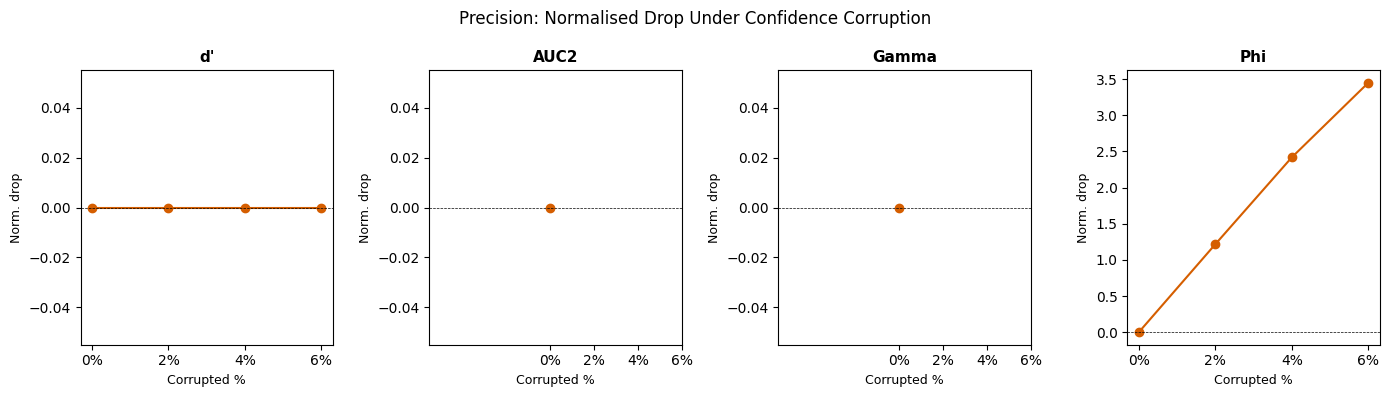

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)
for m, (name, ax) in enumerate(zip(FAST_LABELS, axes)):
    ax.plot(PROPORTIONS, drops[:, m], marker="o", color="#d55e00")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Corrupted %", fontsize=9)
    ax.set_ylabel("Norm. drop", fontsize=9)
    ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
    ax.set_xticks(PROPORTIONS)
    ax.set_xticklabels([f"{int(p*100)}%" for p in PROPORTIONS])

plt.suptitle("Precision: Normalised Drop Under Confidence Corruption", fontsize=12)
plt.tight_layout()
plt.show()


## Summary

You have now covered the complete benchmarking pipeline from Rahnev (2025):

1. **Tutorial 1** — Install check and input format
2. **Tutorial 2** — All 20 measures (absolute, efficiency, noise/uncertainty)
3. **Tutorial 3** — Bootstrap CIs, permutation tests, group summaries
4. **Tutorial 4** — Difficulty dependence + 3-SD outlier removal + ANOVA
5. **Tutorial 5** — Metacognitive bias via Xue recoding
6. **Tutorial 6** (this notebook) — Split-half reliability + precision

For the full 10-dataset replication with MLE-based measures, see the
`notebooks/` directory in the repository.